# Process
### EXPLORATORY DATA ANALYSIS
### FEATURE ENGINEERING
### DATA PREPROCESSING
### DATA LOADING
### MODEL BUILDING
### MODEL TRAINING
### MODULARIZATION
### EXPERIMENT TRACKING
### MODEL EVALUATION
### INFERENCE PIPELINE
### API DEPLOYMENT
### DOCKERIZATION AND DCLOUD DEPLYOMENT 


# EXPLORATORY DATA ANALYSIS

## 1. Overview
## 2. Data Loading and Overview
## 3. Missing Values
## 4. Categorizing Data
## 5. Univariate Analysis
## 6. Bivariate Analysis
## 7. Correlations and Insights
## 8. Conclusions 

## 1. Overview

- This Stage is for the Exploratory Data Analysis of the Heart Disease csv data. 
- This process helps to identify any insights that could help with better training of the model
- the cell below is where is install all the dependencies needed for the EDA, along with styles and theme

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="deep", context="talk")

## 2. Data Collection and Data Separation


- This stage loads the data and gives meaning to the feature labels
- the data comes from the heart disease csv https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- In this stage, I also sepearate the features and targets, for better analysis
- the dataset has 14 columns and 1025 rows
#### Feature Context
- age = age: 29-77
- sex = what is the sex of the person: 1 = male, 0 = female
- trestbps = resting blood pressure: 94-200mm Hg
- cp = chest pain type (4 values): 0,1,2,3
- chol = serum cholestoral in mg/dl: 126 - 564 mg/dl
- fbs = fasting blood sugar > 120 mg/dl: 1 = true, 0 = false
- restecg = resting electrocardiographic results (values 0,1,2): 0-2
- thalach = maximum heart rate achieved: 71 - 202
- exang = exercise induced angina: 1 = yes, 0 = no
- oldpeak = ST depression induced by exercise relative to rest: 0-6.2
- slope = the slope of the peak exercise ST segment: 0-2
- ca = number of major vessels (0-3) colored by flourosopy: 0-3
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- The names and social security numbers of the patients were recently - removed from the database, replaced with dummy values.

#### 2.1 Data collection and Display

In [57]:
# data collection
data_frame = pd.read_csv('../data/raw/heart_disease.csv')
# getting the shape of the data
print(data_frame.shape)
# showing base information
display(data_frame.head())
display(data_frame.sample(5))
print(data_frame.dtypes)


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
369,51,1,2,110,175,0,1,123,0,0.6,2,0,2,1
294,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
580,46,1,1,101,197,1,1,156,0,0.0,2,0,3,1
720,64,1,2,140,335,0,1,158,0,0.0,2,0,2,0
598,58,1,1,120,284,0,0,160,0,1.8,1,0,2,0


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


#### 2.2 Data Seperation 
- Now we must Seperate the data into targets and features

In [58]:
# extract target from features
target_values = data_frame['target']
target = 'target'
features = [c for c in data_frame.columns if c != target]
feature_values = data_frame[features]
display(target_values.sample(10))
display(feature_values.sample(10))

74      0
858     1
852     0
977     1
771     1
1001    1
801     1
201     1
503     1
803     0
Name: target, dtype: int64

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
492,64,1,2,125,309,0,1,131,1,1.8,1,0,3
857,43,1,0,115,303,0,1,181,0,1.2,1,0,2
710,56,1,1,130,221,0,0,163,0,0.0,2,0,3
833,55,1,0,140,217,0,1,111,1,5.6,0,0,3
199,50,1,0,144,200,0,0,126,1,0.9,1,0,3
906,42,1,0,140,226,0,1,178,0,0.0,2,0,2
200,62,0,0,124,209,0,1,163,0,0.0,2,0,2
138,47,1,2,138,257,0,0,156,0,0.0,2,0,2
296,67,1,0,120,237,0,1,71,0,1.0,1,0,2
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2


## 3. Data Checks 
in this stage, i handle various data checks before i go into analysis
- checking for any missing values
- display missing values into a heatmap
- checking for any duplcates, and getting rid of them, if present
- checking data types
- check the statistics of this dataset

#### 3.1 Handling Missing Data
- Missing data is handled by computing the missing and their percentages

In [59]:
# compute missing values AND their percentages
missing_data = data_frame.isna().sum().sort_values(ascending=False)
missing_percentage = (missing_data/len(data_frame))*100
pd.concat([missing_data, missing_percentage], axis=1, keys=['count','percentage']).head(20)


,count,percentage
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalach,0,0.0
exang,0,0.0
oldpeak,0,0.0


#### 3.2 Displaying Any Missing Data


Text(0.5, 1.0, 'Missingness Map')

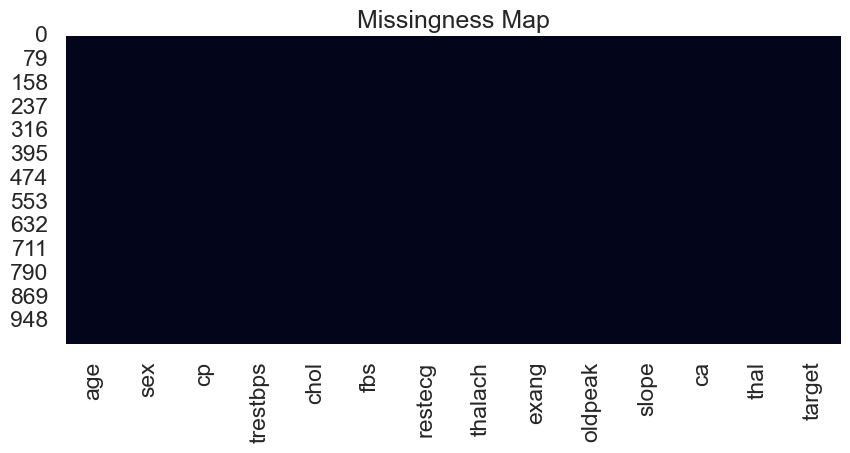

In [60]:
# visualize the missingness matrix through a heatmap
plt.figure(figsize=(10,4))
sns.heatmap(data_frame.isna(), cbar=False)
plt.title("Missingness Map")

#### 3.3 Checking for Duplicates

In [61]:
num_duplicated = data_frame.duplicated().sum()
num_duplicated

np.int64(723)

There are 723 Duplicates. Let's find out why

In [62]:
data_frame[data_frame.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


#### 3.3.1 Drop Exact duplicates of Data

In [63]:
data_frame = data_frame.drop_duplicates()
data_frame

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [64]:
data_frame[data_frame.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


#### 3.4 Checking Data Types

In [65]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


#### 3.5 Checking Data Statistics

In [66]:
data_frame.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 4. Categorizing Data
in this step, i will handled any features that have 'category' values; unique set of values that each row is assigned. doing this will save space in memory, (very important). This also make analysis and modelling easier down the road.
- take category features and convert them into actual category dtypes
- overview of new categories

#### 4.1 Convert Category Features into category dtype

In [67]:
# ensure correct data dtypes for analysis and modeling
'''
    some of the categorical data is in int64 form. so we will instead, 
    look for the features that have few unique values.

    We will treat columns with few unique values or string data as categorical
'''
categ_columns = [col for col in data_frame.columns 
                 if data_frame[col].dtype == 'object' or
                 (data_frame[col].nunique() < 5 and data_frame[col].dtype in ['int64', 'float64'])]

print(categ_columns)
# convert the category features to type 'category'
for c in categ_columns:
    data_frame[c] = data_frame[c].astype('category')

# verify this type change
data_frame.info()

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       302 non-null    int64   
 1   sex       302 non-null    category
 2   cp        302 non-null    category
 3   trestbps  302 non-null    int64   
 4   chol      302 non-null    int64   
 5   fbs       302 non-null    category
 6   restecg   302 non-null    category
 7   thalach   302 non-null    int64   
 8   exang     302 non-null    category
 9   oldpeak   302 non-null    float64 
 10  slope     302 non-null    category
 11  ca        302 non-null    int64   
 12  thal      302 non-null    category
 13  target    302 non-null    category
dtypes: category(8), float64(1), int64(5)
memory usage: 20.0 KB


#### 4.2 Overview of New Category Features

In [68]:
for c in categ_columns:
    print(f"These are the category values of Feature {c}: {data_frame[c].unique()}")

These are the category values of Feature sex: [1, 0]
Categories (2, int64): [0, 1]
These are the category values of Feature cp: [0, 1, 2, 3]
Categories (4, int64): [0, 1, 2, 3]
These are the category values of Feature fbs: [0, 1]
Categories (2, int64): [0, 1]
These are the category values of Feature restecg: [1, 0, 2]
Categories (3, int64): [0, 1, 2]
These are the category values of Feature exang: [0, 1]
Categories (2, int64): [0, 1]
These are the category values of Feature slope: [2, 0, 1]
Categories (3, int64): [0, 1, 2]
These are the category values of Feature thal: [3, 2, 1, 0]
Categories (4, int64): [0, 1, 2, 3]
These are the category values of Feature target: [0, 1]
Categories (2, int64): [0, 1]


## 5. Univariate Analysis
This is where we analysis each individual column to find some insights
- Target Distribution Analysis 
- Categorical Feature Distribution Analysis
- 

46     1
60     1
611    0
13     0
279    1
113    0
189    0
337    1
300    1
472    1
Name: target, dtype: category
Categories (2, int64): [0, 1]

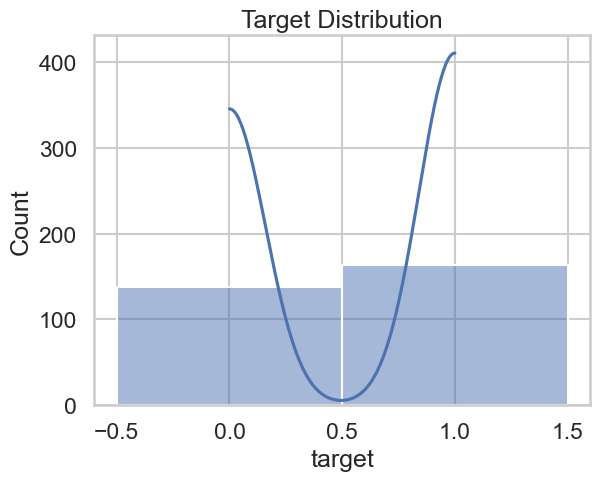

In [69]:
# univariate analysis - target first
'''
    we now must understand target distributions
'''
display(data_frame[target].sample(10))
data_frame[target].describe()
sns.histplot(data_frame[target], kde=True)
plt.title('Target Distribution')
plt.show()


count    302.00000
mean      54.42053
std        9.04797
min       29.00000
25%       48.00000
50%       55.50000
75%       61.00000
max       77.00000
Name: age, dtype: float64


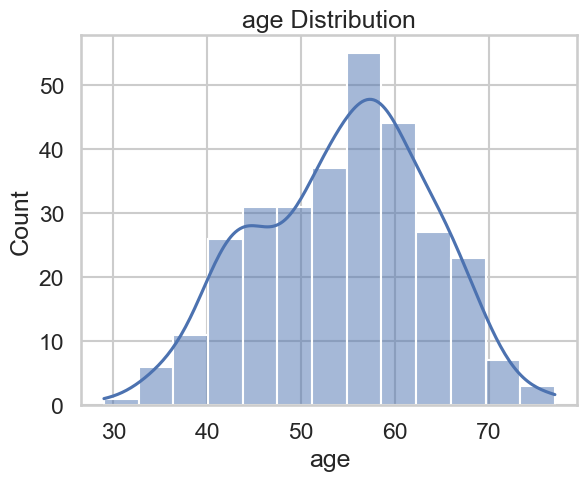

count    302.000000
mean     131.602649
std       17.563394
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64


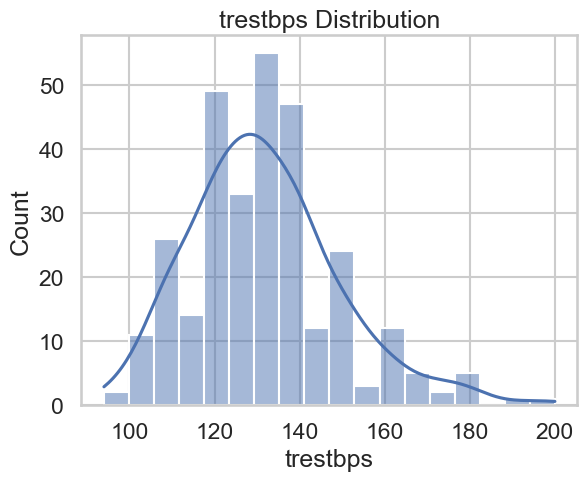

count    302.000000
mean     246.500000
std       51.753489
min      126.000000
25%      211.000000
50%      240.500000
75%      274.750000
max      564.000000
Name: chol, dtype: float64


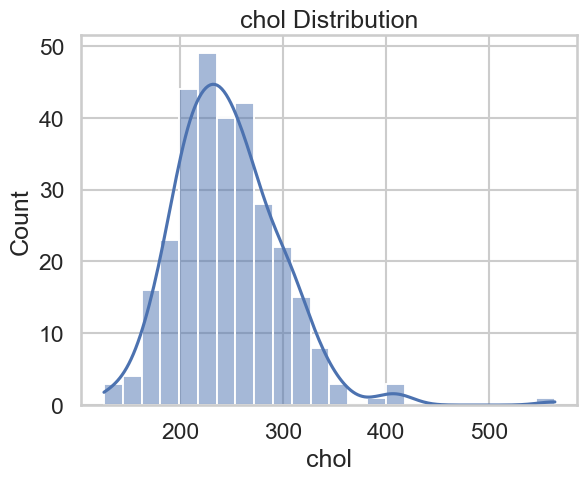

count    302.000000
mean     149.569536
std       22.903527
min       71.000000
25%      133.250000
50%      152.500000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64


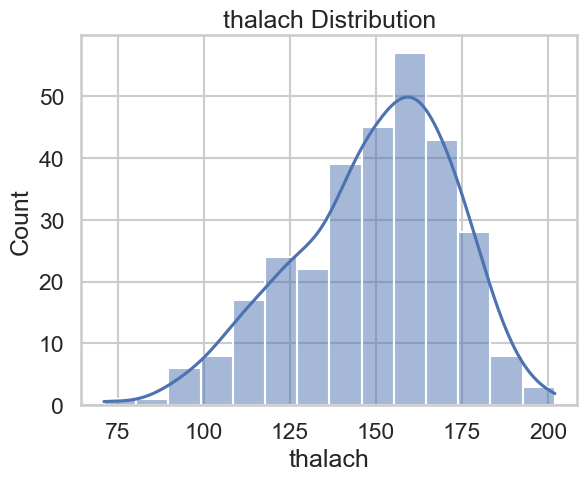

count    302.000000
mean       1.043046
std        1.161452
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64


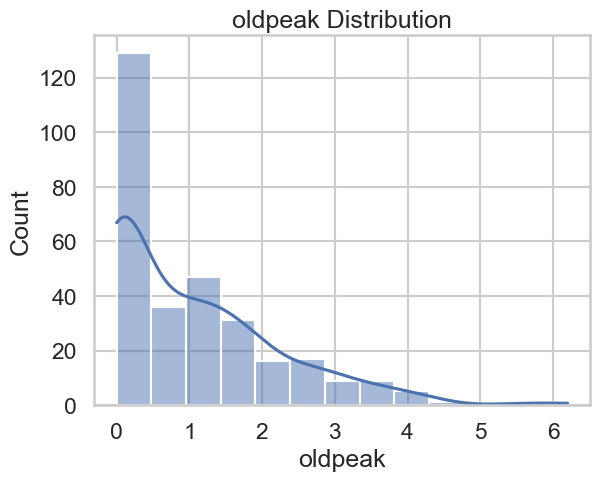

count    302.000000
mean       0.718543
std        1.006748
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        4.000000
Name: ca, dtype: float64


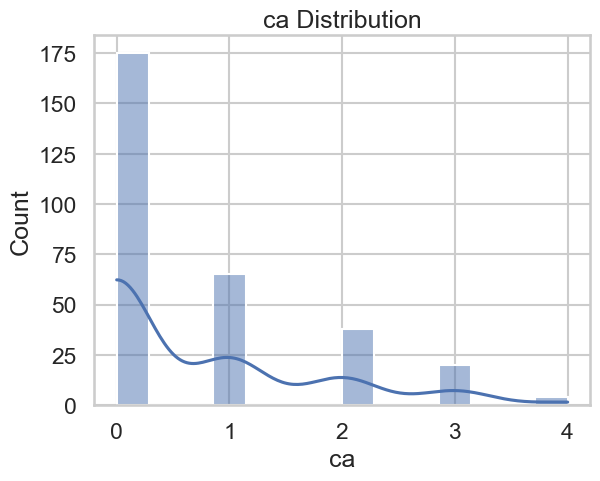

In [54]:
# univariate analysis - ALL PREDICTORS
'''
    all the predictors are the features of the dataframe
'''

# make distribution for numerical features
numerical_colums = data_frame.select_dtypes(include=['int64', 'float64']).columns
for c in numerical_colums:
    print(data_frame[c].describe())
    sns.histplot(data_frame[c].dropna(), kde=True)
    plt.title(f'{c} Distribution')
    plt.show()

sex count     1025
unique       2
top          1
freq       713
Name: sex, dtype: int64


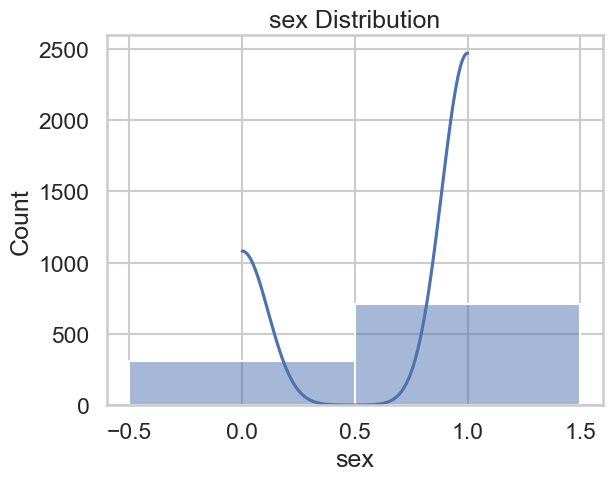

cp count     1025
unique       4
top          0
freq       497
Name: cp, dtype: int64


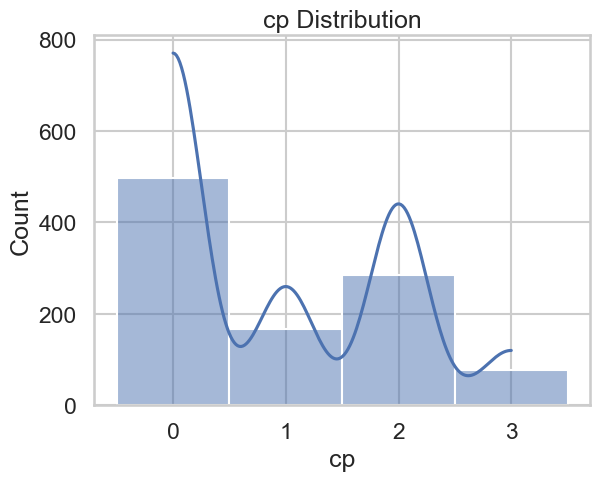

fbs count     1025
unique       2
top          0
freq       872
Name: fbs, dtype: int64


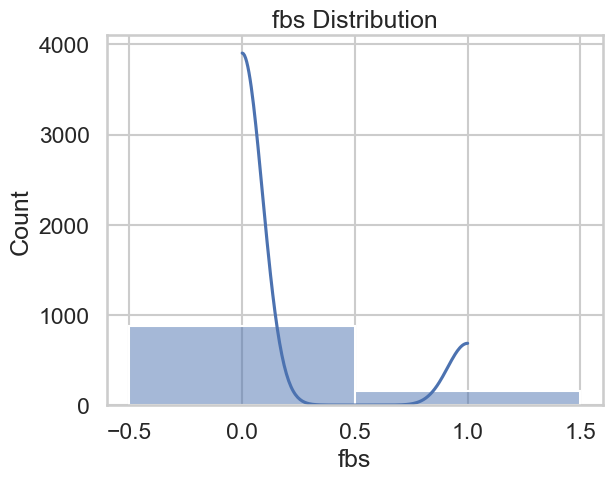

restecg count     1025
unique       3
top          1
freq       513
Name: restecg, dtype: int64


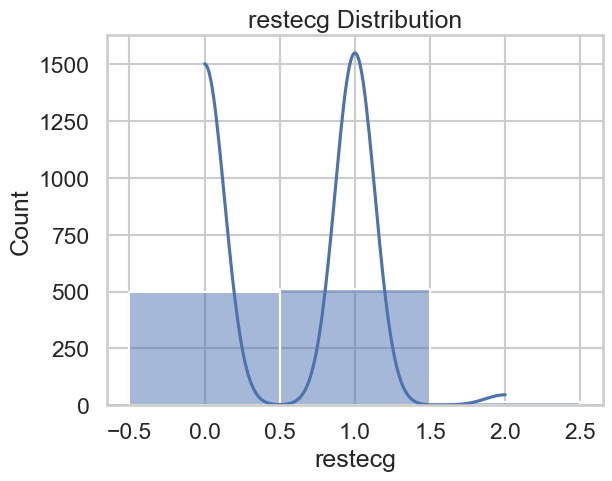

exang count     1025
unique       2
top          0
freq       680
Name: exang, dtype: int64


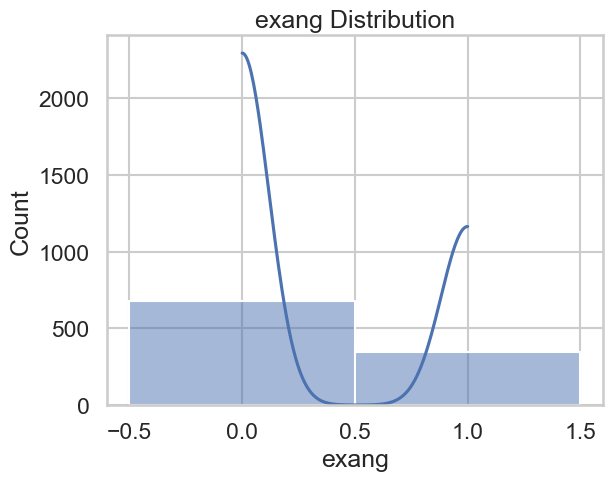

slope count     1025
unique       3
top          1
freq       482
Name: slope, dtype: int64


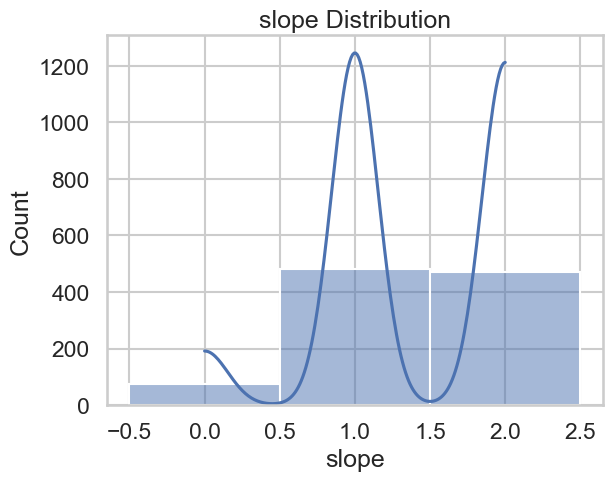

thal count     1025
unique       4
top          2
freq       544
Name: thal, dtype: int64


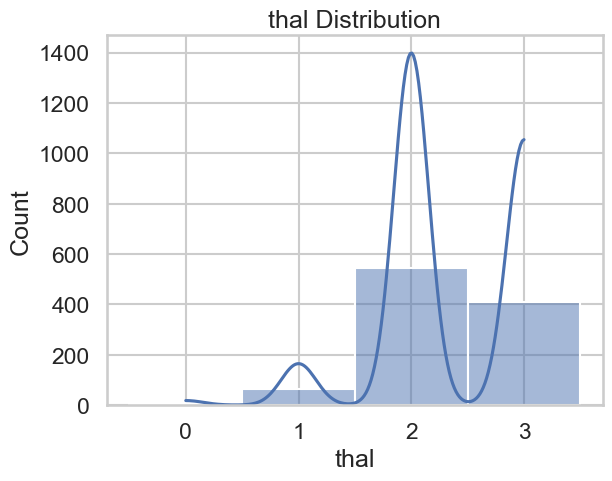

In [ ]:
# get only categorical features

# data_frame[col].dtype == 'object'
categorical_colums = data_frame.select_dtypes(include=['category']).columns
cat_features = [c for c in categorical_colums if c != "target"]
for c in data_frame[cat_features].columns:
    print(c, data_frame[c].describe())
    sns.histplot(data_frame[c].dropna(), kde=True)
    plt.title(f'{c} Distribution')
    plt.show()

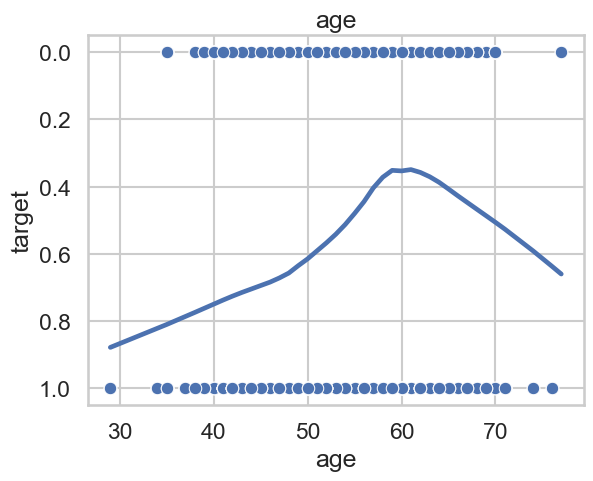

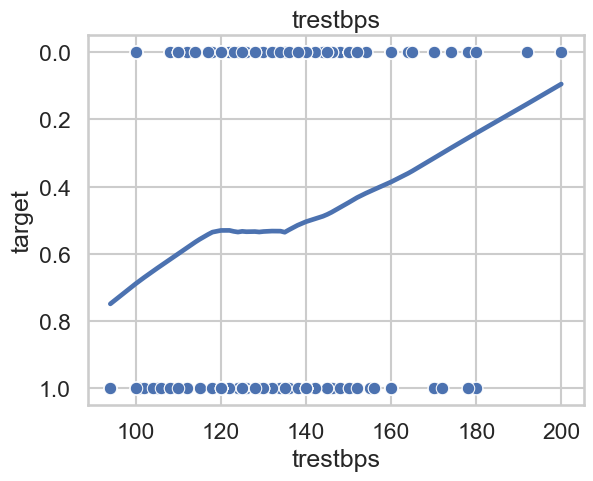

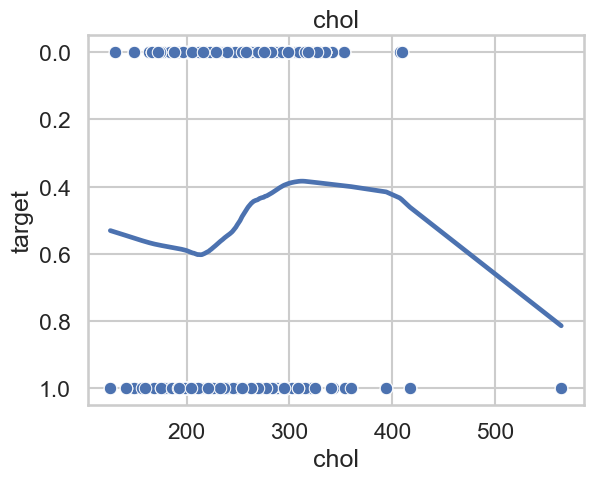

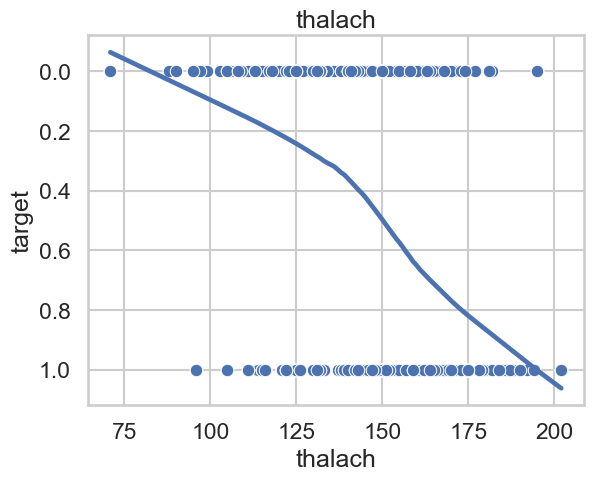

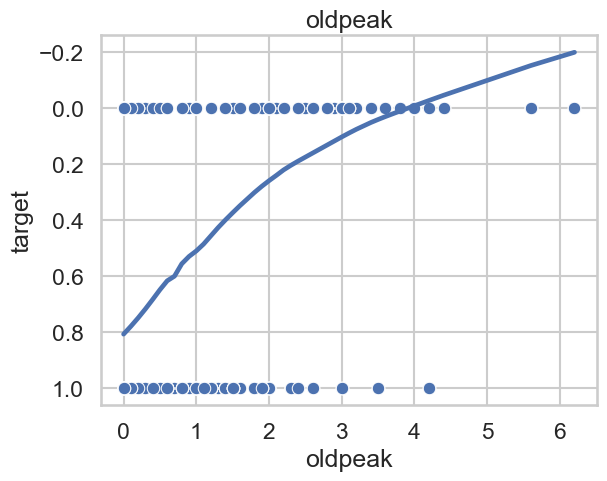

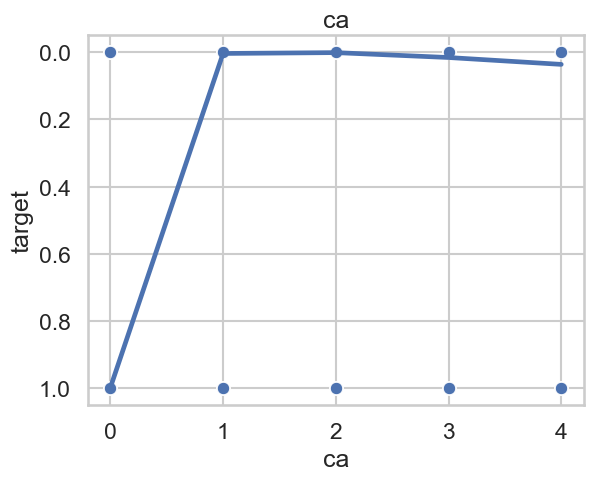

In [ ]:
# Bivariate Analysis - feature vs target

for c in numerical_colums:
    sns.scatterplot(x=data_frame[c], y=data_frame[target])
    sns.regplot(x=data_frame[c], y=data_frame[target], lowess=True, scatter=False, ci=None)
    plt.title(c)
    plt.show()

,features,VIF
1,trestbps,55.332034
0,age,37.677299
3,thalach,29.575300
2,chol,24.335197
4,oldpeak,2.174525
5,ca,1.718157


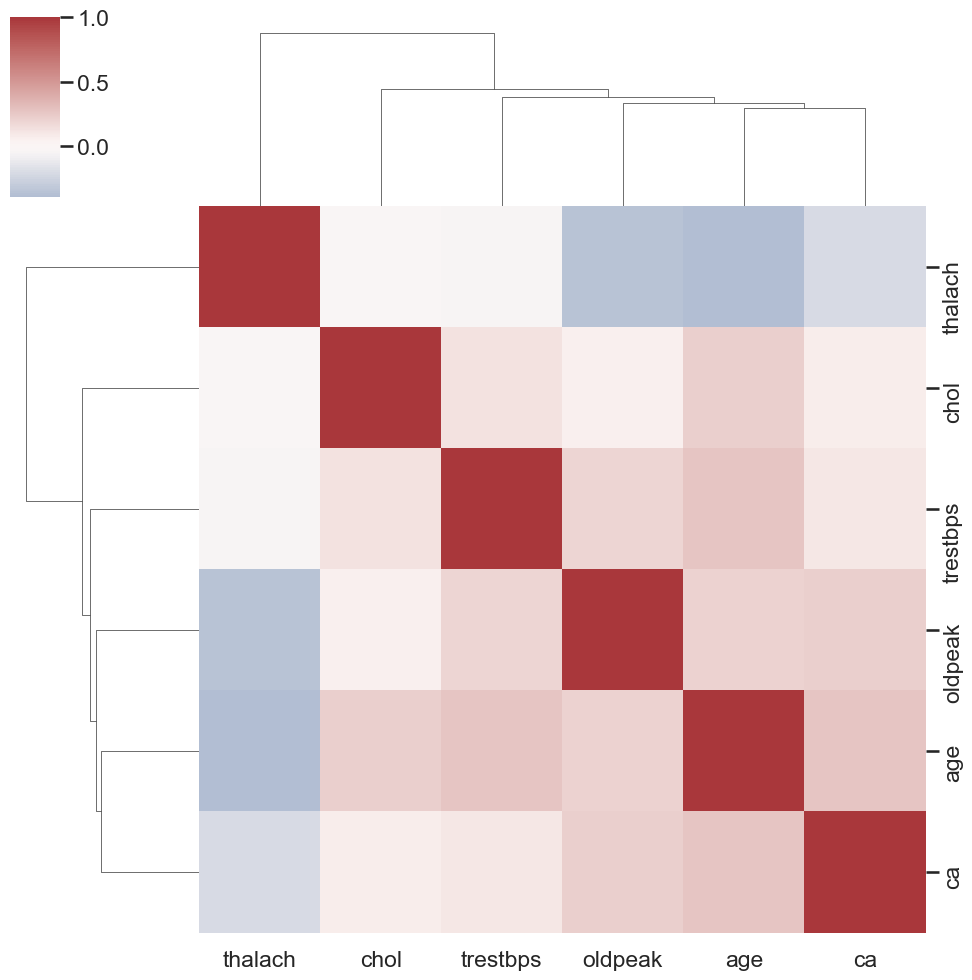

In [ ]:
# correlation structure & multicollinearity
corr = data_frame[numerical_colums].corr()
sns.clustermap(corr, figsize=(10,10), cmap='vlag', center=0)

# VIF
X = data_frame[numerical_colums].dropna()
vif = pd.DataFrame({'features': X.columns, 'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif.sort_values('VIF', ascending=False)

In [ ]:
# outliers and Leverage Points

# detection of influential rows that can distort linear regression

# z-scores and IQR outliers for num features
from scipy import stats
z = np.abs(stats.zscore(data_frame[numerical_colums].dropna()))
outlier_rows = (z > 3).any(axis=1)
data_frame.loc[outlier_rows].shape

(49, 14)

In [ ]:
data_frame.dtypes

age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca             int64
thal        category
target      category
dtype: object

In [ ]:
# save new data to processed data folder
data_frame_cleaned = data_frame.copy()

data_frame_cleaned.to_csv('../data/processed/heart_disease_cleaned.csv', index=False)
print("Saved cleaned data to ../data/processed/eda_cleaned.csv")


Saved cleaned data to ../data/processed/eda_cleaned.csv
